Group Members: Navpreet Kloy, Aidan Gonzales, Mauricio Ferreyra-Ruiz (Monday & Wednesday)

Dataset:https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

In [14]:
# Import necessary libraries
import xgboost as xgb  # XGBoost library for gradient boosting
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix  # For evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# load dataset
df = pd.read_csv("alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [16]:
# dataset overview
df.info()
print('\nDataset shape (samples, features):', df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [17]:
# define the X features and y (output label)
X = df.drop(["Diagnosis", "DoctorInCharge", "PatientID", "Ethnicity","MMSE"], axis=1)  # Input features
y = df["Diagnosis"]                                    # Output label

In [18]:
# view target distribution
# where 0 indicates No and 1 indicates Yes for diagnosis status for Alzheimer's Disease
df['Diagnosis'].value_counts()

,count
Diagnosis,
0,1389
1,760


In [19]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  # 30% for testing
    random_state=42,
    stratify=y  # Maintain class proportions in both sets
)


In [20]:
# Initialize XGBoost Classifier
model = xgb.XGBClassifier(
    max_depth=3,           # Maximum depth of each tree
    n_estimators=50,       # Number of boosting rounds
    learning_rate=0.1,     # Step size shrinkage
    objective='binary:logistic',  # Binary classification with probability output
    random_state=42,
    eval_metric='logloss'  # Evaluation metric during training
)

# Train the model on training set
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
# Evaluate the model

# predict on test set
y_test_pred = model.predict(X_test)

# accuracy for generalization
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")         # print model accuracy


# Classification Report for model
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))   # display metrics to evaluate model

Accuracy: 84.96%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       417
           1       0.76      0.83      0.80       228

    accuracy                           0.85       645
   macro avg       0.83      0.85      0.84       645
weighted avg       0.85      0.85      0.85       645



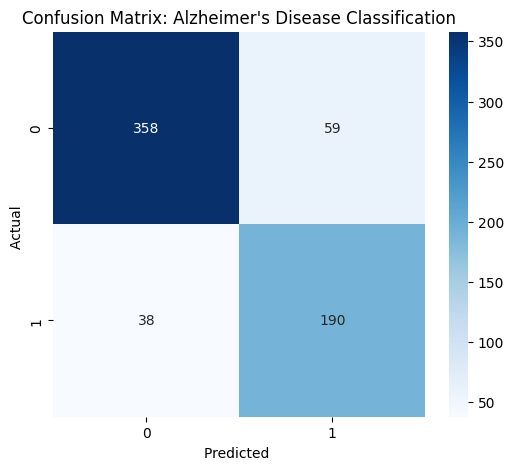

In [22]:
# Confusion matrix  -- view diagnosis predicted vs actual
cm = confusion_matrix(y_test,y_test_pred )

# define class labels for plot
labels = model.classes_

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels= labels, yticklabels=labels)
plt.xlabel('Predicted ')
plt.ylabel('Actual ')
plt.title("Confusion Matrix: Alzheimer's Disease Classification")
plt.show()

The point of this XGBM model is to predict the probability of Alzheimer's diagnosis yes or no, based on the selected features. For inputs selection, out of a total of 35 features in the dataset, five features were dropped as the inputs, including the target. The rest were kept. The features are composed of various health markers, clinical measurements factors.

The main purpose of this model is to know what features are most important in predicting Alzheimer's diagnosis, and to be able to predict the probability of a patient having Alzheimer's based on their features. The model had 84.96% accuracy.  It is less precise at predicting if a patient does have Alzheimer's Disease. There is also concern of falsing predicting no Alzheimer's Disease, when the disease is actually present. In this model, the test set missed 38 out of 228 actual  Alzheimer's Disease outcomes. Overall, the model has a bit stronger performance in correctly identifying a diagnosis of no for Alzheimer's Disease.


This model be used to help doctors and patients make informed decisions about their health, and to identify potential risk factors for Alzheimer's disease.